# Q9 - Parkinson’s Dataset with Logistic

This dataset is composed of a range of biomedical voice measurements from 31 people, 23 with Parkinson's disease (PD) and eight healthy controls. The main aim of the data is to discriminate between healthy people and those with PD, based on the voice measurements.

>The dataset contains 23 features, including:

*   MDVP:Fo(Hz) - Average vocal fundamental frequency
*  MDVP:Fhi(Hz) - Maximum vocal fundamental frequency
*  MDVP:Flo(Hz) - Minimum vocal fundamental frequency
*  And various measures of vocal jitter and shimmer, as well as other acoustic features.
<br>The target variable is 'status', which is 1 for people with Parkinson's and 0 for healthy individuals.

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Data Loading and Visualization

In [23]:
# Load Parkinson's dataset
parkinsons_url = "http://archive.ics.uci.edu/ml/machine-learning-databases/parkinsons/parkinsons.data"
df_parkinsons = pd.read_csv(parkinsons_url)

# Display the first few rows and summary statistics
display(df_parkinsons.head())
display(df_parkinsons.describe())

# Separate features and target
X_parkinsons = df_parkinsons.drop(['name', 'status'], axis=1)
y_parkinsons = df_parkinsons['status']



,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
count,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,...,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000
mean,154.228641,197.104918,116.324631,0.006220,0.000044,0.003306,0.003446,0.009920,0.029709,0.282251,...,0.046993,0.024847,21.885974,0.753846,0.498536,0.718099,-5.684397,0.226510,2.381826,0.206552
std,41.390065,91.491548,43.521413,0.004848,0.000035,0.002968,0.002759,0.008903,0.018857,0.194877,...,0.030459,0.040418,4.425764,0.431878,0.103942,0.055336,1.090208,0.083406,0.382799,0.090119
min,88.333000,102.145000,65.476000,0.001680,0.000007,0.000680,0.000920,0.002040,0.009540,0.085000,...,0.013640,0.000650,8.441000,0.000000,0.256570,0.574282,-7.964984,0.006274,1.423287,0.044539
25%,117.572000,134.862500,84.291000,0.003460,0.000020,0.001660,0.001860,0.004985,0.016505,0.148500,...,0.024735,0.005925,19.198000,1.000000,0.421306,0.674758,-6.450096,0.174351,2.099125,0.137451
50%,148.790000,175.829000,104.315000,0.004940,0.000030,0.002500,0.002690,0.007490,0.022970,0.221000,...,0.038360,0.011660,22.085000,1.000000,0.495954,0.722254,-5.720868,0.218885,2.361532,0.194052
75%,182.769000,224.205500,140.018500,0.007365,0.000060,0.003835,0.003955,0.011505,0.037885,0.350000,...,0.060795,0.025640,25.075500,1.000000,0.587562,0.761881,-5.046192,0.279234,2.636456,0.252980
max,260.105000,592.030000,239.170000,0.033160,0.000260,0.021440,0.019580,0.064330,0.119080,1.302000,...,0.169420,0.314820,33.047000,1.000000,0.685151,0.825288,-2.434031,0.450493,3.671155,0.527367


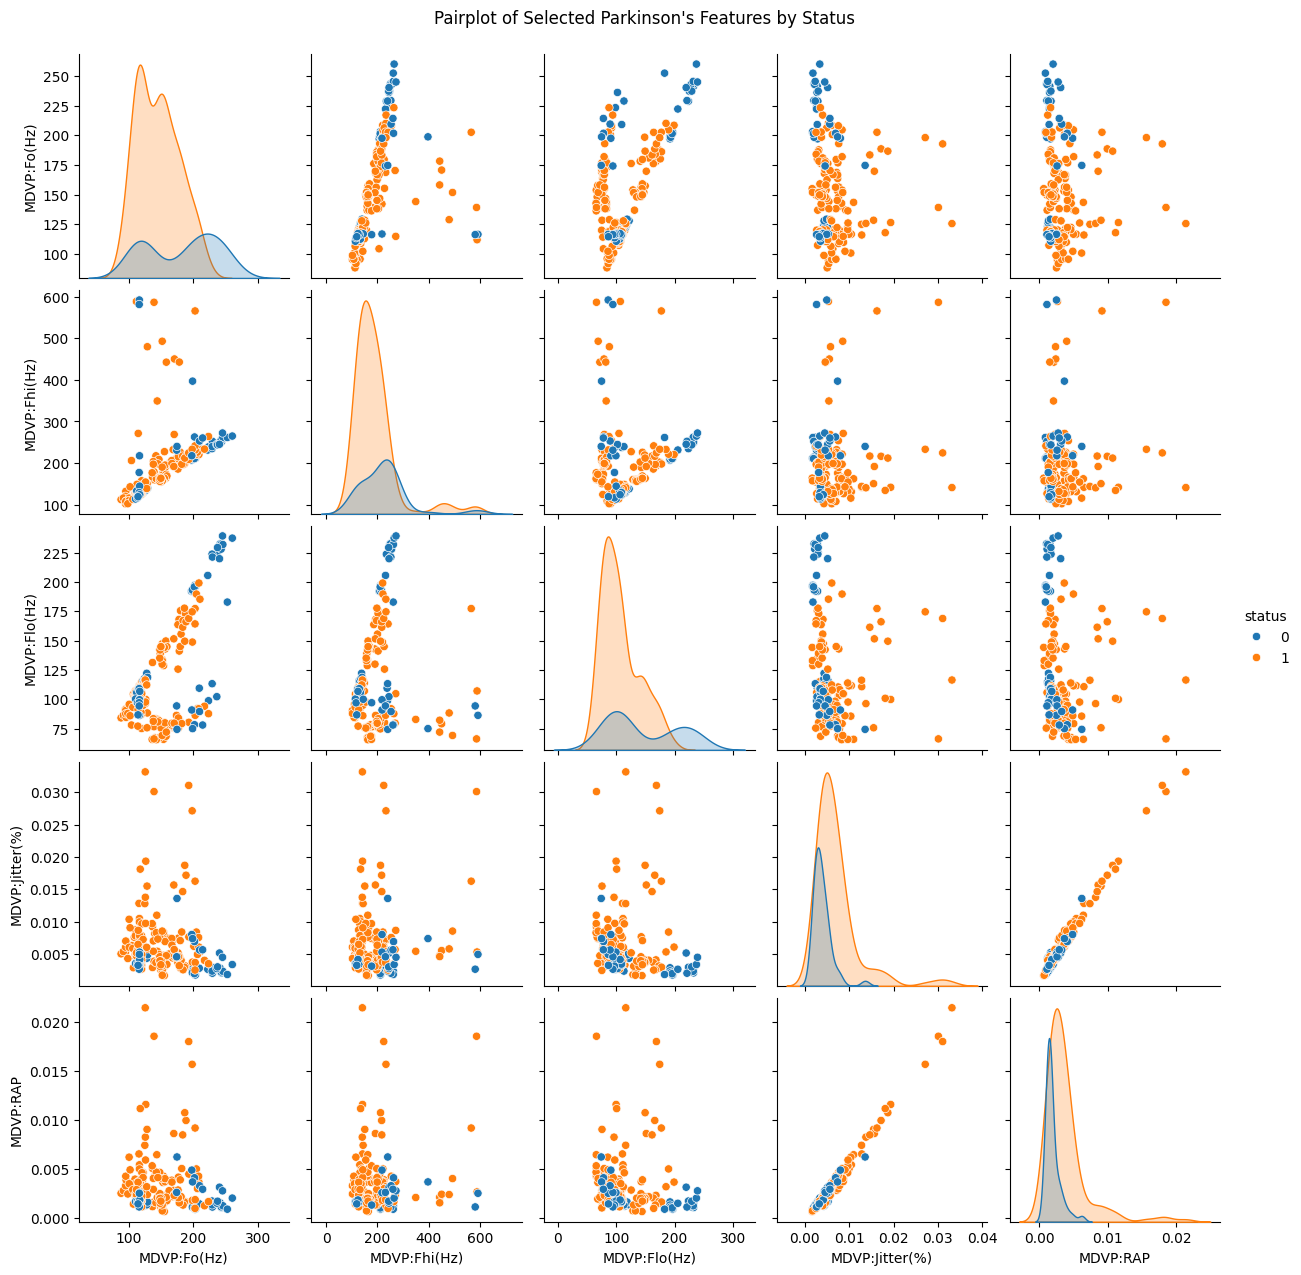

In [12]:
# Visualize the data (pairplot for a subset of features due to high dimensionality)
# Selecting a few features for visualization
selected_features = ['MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(%)', 'MDVP:RAP', 'status']
sns.pairplot(df_parkinsons[selected_features], hue="status")
plt.suptitle("Pairplot of Selected Parkinson's Features by Status", y=1.02)
plt.show()

**Question 1**

 From the scatterplot/pairplot above which two features seem most useful for separating species?

Answer : <br>
 Looking at the pairplot, features like PPE (Jitter), spread1, and D2 seem to show some separation between the two classes (status 0 and 1). Also, features like MDVP:Fo(Hz), MDVP:Fhi(Hz), and MDVP:Flo(Hz) show different distributions for the two classes.

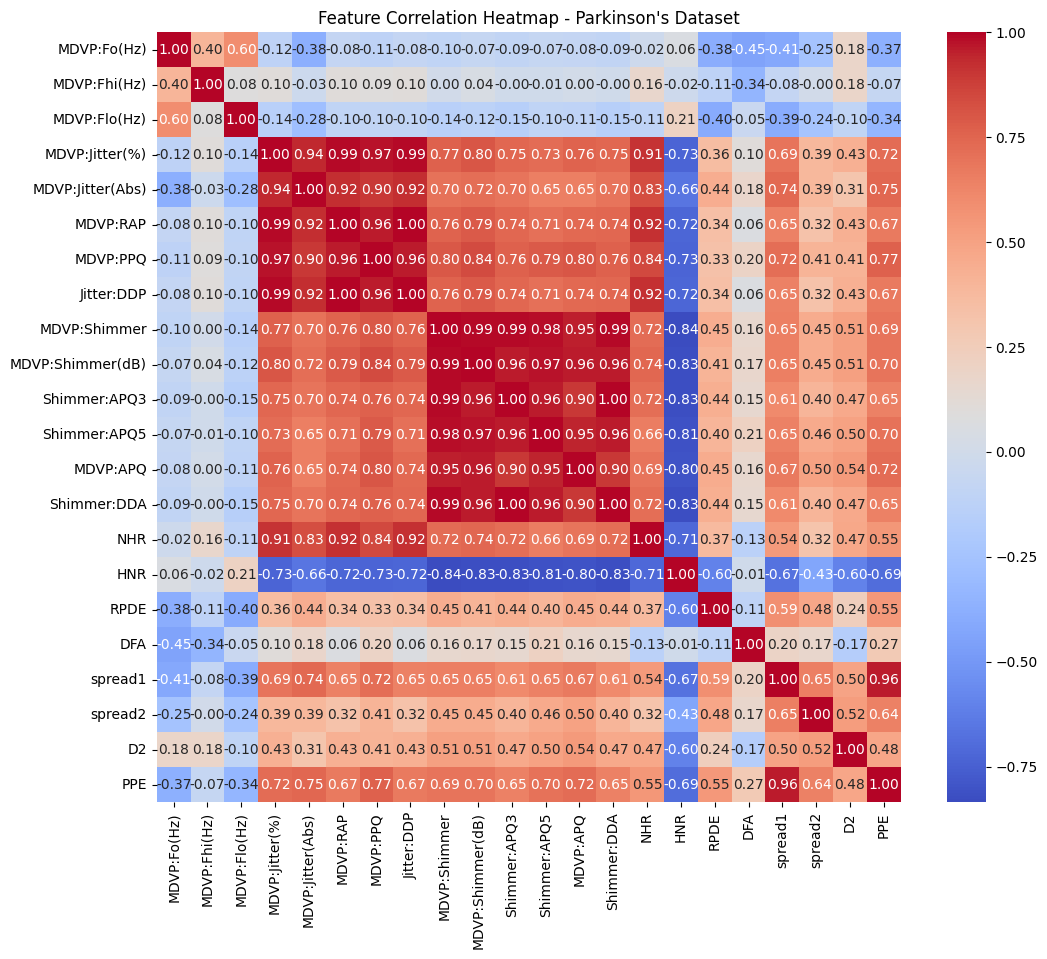

In [13]:
# Visualize correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(X_parkinsons.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap - Parkinson's Dataset")
plt.show()

**Question 2**

Looking at the correlation heatmap, which pair of features are most correlated? What might this imply?

Answer :<br>
There are several pairs of highly correlated features in the Parkinson's dataset, for example, MDVP:Jitter(%), MDVP:RAP, MDVP:PPQ, and Jitter:DDP are all highly correlated with each other (around 0.97-1.00). Similarly, MDVP:Shimmer, MDVP:Shimmer(dB), Shimmer:APQ3, Shimmer:APQ5, MDVP:APQ, and Shimmer:DDA are also highly correlated among themselves (around 0.8-1.00). This high correlation suggests multicollinearity among these features, which means some of them might be redundant and could potentially be removed or combined.

# Train/Test Split

In [14]:
# Train/Test Split for Parkinson's dataset

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(X_parkinsons, y_parkinsons, test_size=0.3, random_state=42, stratify=y_parkinsons)
print("\nParkinson's Dataset - Training samples:", X_train_p.shape[0])
print("Parkinson's Dataset - Test samples:", X_test_p.shape[0])



Parkinson's Dataset - Training samples: 136
Parkinson's Dataset - Test samples: 59


 **Question 3**.

  Why do we split the dataset into training and testing sets?

Answer :
<br> Same reason as with the Iris dataset: To evaluate model performance on unseen data. Training is used to learn patterns, while testing checks generalization ability and prevents overfitting. This is especially important in medical datasets like Parkinson's to ensure the model can generalize to new patients.

# Logistic Regression



Accuracy (Logistic Regression): 0.847457627118644

Classification Report (Logistic Regression):
               precision    recall  f1-score   support

           0       0.69      0.73      0.71        15
           1       0.91      0.89      0.90        44

    accuracy                           0.85        59
   macro avg       0.80      0.81      0.80        59
weighted avg       0.85      0.85      0.85        59



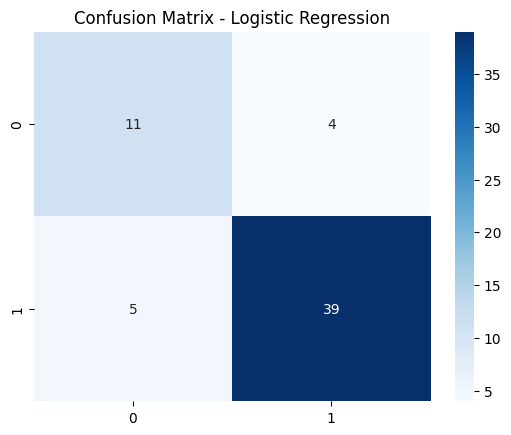

In [8]:
# Logistic Regression

log_reg = LogisticRegression(max_iter=500)
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)
print("\nAccuracy (Logistic Regression):", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report (Logistic Regression):\n", classification_report(y_test,
y_pred_lr))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

**Question 4.**

 Logistic Regression assumes a linear decision boundary. why?

Answer :  <br>
Same reason as with the Iris dataset: Because it models the log-odds of the target as a linear combination of the features. The decision boundary occurs where probability = 0.5, which results in a linear hyperplane.

**Question 5.**

Do you think this assumption holds for the Iris dataset? Why or why not?

Answer : <br>
For the Parkinson's dataset, the relationship between features and the 'status' is likely complex and non-linear. While logistic regression can capture some linear relationships, the higher dimensionality and potential interactions between features in this dataset might mean that the linear decision boundary assumption is less likely to hold perfectly compared to simpler datasets like Iris.


## Random Forest


Accuracy (Random Forest): 0.9322033898305084

Classification Report (Random Forest):
               precision    recall  f1-score   support

           0       0.92      0.80      0.86        15
           1       0.93      0.98      0.96        44

    accuracy                           0.93        59
   macro avg       0.93      0.89      0.91        59
weighted avg       0.93      0.93      0.93        59



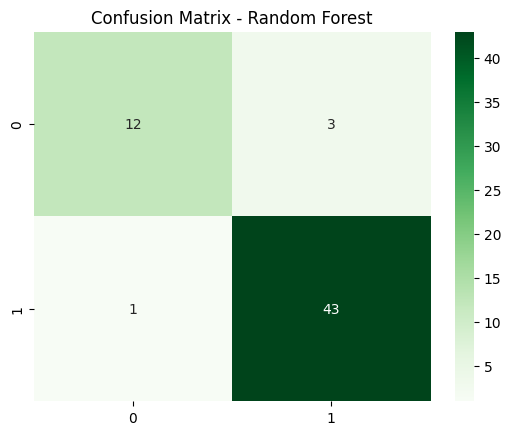

In [15]:
# Random Forest

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("\nAccuracy (Random Forest):", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report (Random Forest):\n", classification_report(y_test,
y_pred_rf))

sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - Random Forest")
plt.show()


**Question 6**.

 If we increased the number of trees (n_estimators) in Random Forest, how might the performance change?

Answer : <br>
Same reason as with the Iris dataset: Performance generally improves (less variance, more stable predictions) up to a point. After that, gains are minimal, but computation cost increases. With a more complex dataset like Parkinson's, increasing n_estimators might have a more significant positive impact initially before plateauing.

**Question 7**.

Between Logistic Regression and Random Forest, which model performed better? Why might that be?

Answer : <br>
In the case of the Parkinson's dataset, the Random Forest model performed significantly better (accuracy ~0.93) than Logistic Regression (accuracy ~0.83).  <br>
This is likely because the Parkinson's dataset is more complex and has more features than the Iris dataset, and the relationships between features and the target variable are likely non-linear. Random Forest, being an ensemble of decision trees, is better equipped to handle such non-linear relationships and complex feature interactions.


**Question 8**.

If we had a much larger dataset with noisy features, which model would you expect to generalize better, and why?

Answer : <br>Random Forest, because it is generally more robust to noise and irrelevant features due to its ensemble nature and the random selection of features for each tree. Logistic Regression is more sensitive to noisy data and multicollinearity.


**Question 9.**<br>Run the Entire Notebook with this dataset separately http://archive.ics.uci.edu/dataset/174/parkinsons. Also Answer the above questions for this dataset too.

Answer:  <br>The code for this was provided and executed in the previous cell.

**Question 10.**

Learn utilising synthetic data in AI using https://www.syngendata.ai to explore the above mentioned data visualisation

Answer : <br>Synthetic data can be a valuable tool for augmenting datasets like the Parkinson's data, especially given its relatively small size. It can help address issues like class imbalance, improve model robustness by providing more diverse examples, and allow for data exploration and visualization techniques to be applied to a larger, synthetically generated dataset that mirrors the characteristics of the original data without compromising privacy.